# Importar Librerías y Configurar el Navegador

In [16]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
from time import sleep
import csv
import os
from datetime import datetime
from random import randint
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.common.exceptions import TimeoutException
from webdriver_manager.chrome import ChromeDriverManager
from selenium.common.exceptions import StaleElementReferenceException
import re

from selenium.common.exceptions import NoSuchElementException
from bs4 import BeautifulSoup, NavigableString

# ORQUESTADOR ----------------------------------------------------------------*


In [18]:
from scraping.extractor_twitter import iniciar_sesion, navegar_a_perfil, extraer_y_guardar_comentarios
#from utils.helpers import configurar_log

# Configuración de logs
#configurar_log()

# FUNCIÓN PRINCIPAL
try:
    # Configuración del navegador
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service)

    # Iniciar sesión
    #iniciar_sesion(driver,user='juan_c.ortiz_b@uao.edu.co', pwd='3127916565', username='@OrtizBaron77043')
    iniciar_sesion(driver,user='jamoncayop@gmail.com', pwd='Adaptiv3@*', username='@Jaime1807816689')
    
    # Navegar al perfil de @Tu_IMSS
    navegar_a_perfil(driver, "https://x.com/Tu_IMSS?f=live")
    print("¡Has iniciado sesión y estás en el perfil de @Tu_IMSS!")

    # Extraer y guardar comentarios de los primeros tweets
    fecha_actual = datetime.now().strftime("%Y-%m-%d")
    nombre_archivo = f"db/cmts_extraidos_{fecha_actual}_jaime.csv"
    extraer_y_guardar_comentarios(driver, nombre_archivo)

except Exception as e:
    print("❌ Error en la ejecución:", e)

finally:
    # Cerrar el navegador
    if driver:
        driver.quit()


✔ Correo ingresado
ℹ No se pidió confirmación adicional de nombre de usuario.
✔ Contraseña ingresada
✔ Se hizo clic en 'Iniciar sesión'
¡Has iniciado sesión y estás en el perfil de @Tu_IMSS!
🔄 Scroll fijo #1/1
🔗 Capturadas 7 URLs de tweets (queríamos 20)

🔹 Procesando URL #1/7: https://x.com/Tu_IMSS/status/1951780050782859331

▶️  Abriendo tweet en nueva pestaña: https://x.com/Tu_IMSS/status/1951780050782859331
    🔄 Replies cargados: 0
    🔄 Replies cargados: 0
  🔍 Tamaño de page_source tras spam: 473937
  💡 Extraído: id=id_¡Cuidado_con_la_resistencia_a_ replies=2
  👤 Autor original: IMSS  @Tu_IMSS
↪️ [guardar_comentarios] para tweet_id=id_¡Cuidado_con_la_resistencia_a_
🔎 oficiales: 0
🔎 spam_cells encontradas: 11, total spam artículos: 5
🔎 total candidatos tras unir: 4
→ auténticas tras filtrar y recortar a 3/2
🔄 Guardando respuesta auténtica #1
🔄 Guardando respuesta auténtica #2
🔄 Guardando respuesta auténtica #3
  🔙 Cerrando pestaña y volviendo…

🔹 Procesando URL #2/7: https://x.co

# Nube de palabras -------------------------------------------------------*

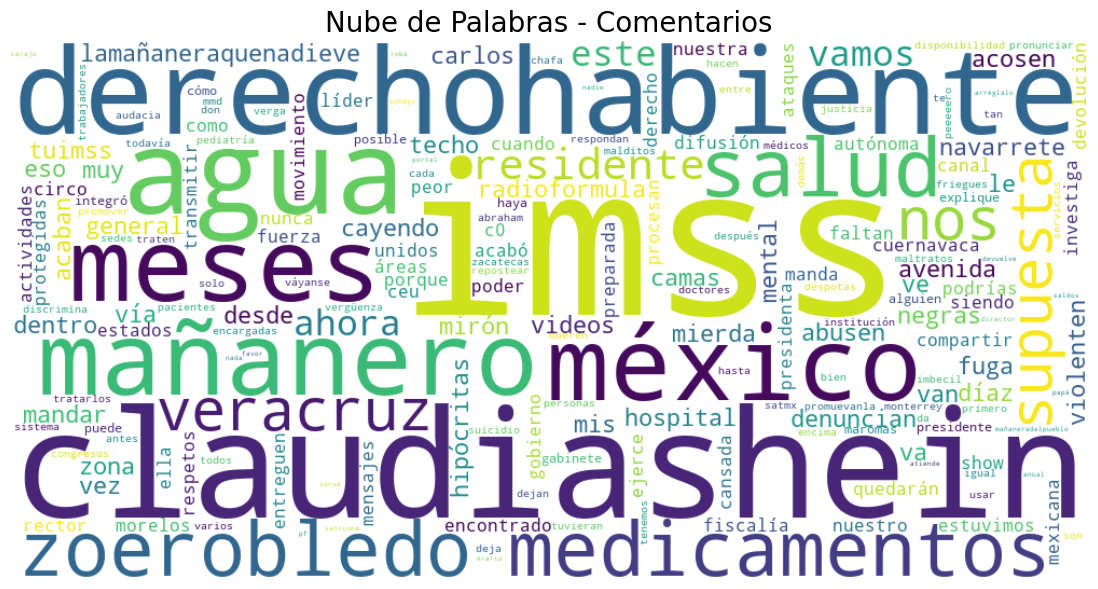

In [7]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Leer el archivo CSV
#df = pd.read_csv("db/comentarios_imss_urls_1333333.csv")
df = pd.read_csv("db/db_procesadas/comentarios_limpios_modi.csv", on_bad_lines='skip')

# Combinar todos los comentarios
texto = " ".join(str(c) for c in df["comentario"].dropna())

# Stopwords en español
stopwords = set(STOPWORDS)
stopwords.update(["https", "rt", "t.co", "si", "no", "tener", "ser", "estar", "del", "por", "para", "con", "más", "menos","hay","de","la","en","y","las",
                  "su","se","lo","el","sin","que","un","una","mi","al","comentario","sus","los","tiene","ya","e","es"])

# Crear y mostrar la nube de palabras
wordcloud = WordCloud(width=1000, height=500, background_color="white", stopwords=stopwords, collocations=False).generate(texto)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Comentarios", fontsize=20)
plt.show()


# Parte 2 Análisis de sentimientos ---------------*


### Ejemplo sencillo ***

In [11]:
df = pd.read_csv("db/db_procesadas/comentarios_limpios_modi.csv", on_bad_lines='skip')

df.info()

df2 = pd.read_csv("db/db_procesadas/comentarios_imss_urls_1333333.csv")

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tweet_id              45 non-null     object 
 1   tweet_text            43 non-null     object 
 2   comentario            43 non-null     object 
 3   comentario_autor      45 non-null     object 
 4   fecha_publicacion     45 non-null     object 
 5   timestamp_extraccion  45 non-null     object 
 6   replies               45 non-null     float64
 7   reposts               45 non-null     int64  
 8   likes                 45 non-null     int64  
 9   views                 37 non-null     float64
 10  tweet_id_nuevo        45 non-null     int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 4.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------        

In [12]:
import pandas as pd
import subprocess
import json
from limpieza.preprocesamiento import limpiar_comentario, normalizar_comillas, limpiar_respuesta_ollama
# Vamos a hacer el merge

def probar_ollama_dataset(indice=10):
    """
    Carga un comentario específico del dataset y lo envía a Ollama para clasificarlo.
    """
    print("📥 [CARGANDO] Leyendo CSV...")
    #df = pd.read_csv("db/comentarios_imss_urls_1333333.csv")
    df = pd.read_csv("db/db_procesadas/comentarios_limpios_modi.csv", on_bad_lines='skip')
    print(f"🔢 [INFO] Total de comentarios: {len(df)}")

    # Obtener un comentario
    comentario_original = str(df["comentario"].iloc[indice])
    print(f"📝 [ORIGINAL] Comentario {indice}: {comentario_original}")

    # Limpiar comentario
    comentario_limpio = limpiar_comentario(normalizar_comillas(comentario_original))
    print(f"🧹 [LIMPIO] {comentario_limpio}")

    # Crear prompt
    prompt = f"""
    Analiza el siguiente comentario:
    "{comentario_limpio}"
    Devuelve únicamente un JSON válido con esta estructura:
    {{
      "sentimiento": "positivo | negativo | neutro",
      "categoria": "queja | elogio | otro"
    }}
    No incluyas explicaciones, comentarios ni bloques de código.
    """

    # Enviar a Ollama
    print("🤖 [TEST] Enviando prompt a Ollama...")
    try:
        proceso = subprocess.Popen(
            ["ollama", "run", "mistral"],
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            encoding="utf-8",
            errors="replace"
        )
        salida, error = proceso.communicate(prompt, timeout=60)
        print("[DEBUG] STDOUT:", salida.strip())
        print("[DEBUG] STDERR:", error.strip() if error else "VACÍO")

        # Limpiar la respuesta
        return limpiar_respuesta_ollama(salida)
    except Exception as e:
        print(f"❌ [ERROR] {e}")
        return {"sentimiento": "error", "categoria": "error"}

if __name__ == "__main__":
    resultado = probar_ollama_dataset(indice=0)  # Cambia el índice para otro comentario
    print("✅ [RESULTADO FINAL]:", resultado)


📥 [CARGANDO] Leyendo CSV...
🔢 [INFO] Total de comentarios: 45
📝 [ORIGINAL] Comentario 0: podrías  compartir  las  actividades  que  tiene  el  imss  en  cuernavaca  morelos
🧹 [LIMPIO] podrías compartir las actividades que tiene el imss en cuernavaca morelos
🤖 [TEST] Enviando prompt a Ollama...
[DEBUG] STDOUT: {"categoria": "otro", "sentimiento": "neutro"}
[DEBUG] STDERR: ⠙ ⠹ ⠸ ⠸ ⠴ ⠦ ⠦ ⠧ ⠇ ⠏ ⠙ ⠙ ⠸ ⠸ ⠴ ⠦ ⠧ ⠇ ⠇ ⠏ ⠋ ⠹ ⠸ ⠸ ⠴ ⠦ ⠦ ⠧ ⠏ ⠋ ⠙ ⠹ ⠸ ⠼ ⠼ ⠦ ⠧ ⠧ ⠏ ⠋ ⠙ ⠙ ⠸ ⠼ ⠴ ⠦ ⠦ ⠇ ⠏ ⠏ ⠙ ⠹ ⠸ ⠸ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠹ ⠹ ⠸ ⠴ ⠦ ⠦ 
✅ [RESULTADO FINAL]: {'sentimiento': 'neutro', 'categoria': 'otro'}


### Ejemplo con listado iterando cada comentario ***

In [13]:
import pandas as pd
import subprocess
import json
from limpieza.preprocesamiento import limpiar_comentario, normalizar_comillas, limpiar_respuesta_ollama

def clasificar_dataset_completo():
    """
    Itera sobre todos los comentarios del dataset, los envía a Ollama para clasificar
    y guarda el resultado en un nuevo CSV con la respuesta cruda.
    """
    print("📥 [CARGANDO] Leyendo CSV...")
    df = pd.read_csv("db/db_procesadas/comentarios_imss_urls_1333333.csv")
    print(f"🔢 [INFO] Total de comentarios: {len(df)}")

    resultados = []
    respuestas_crudas = []

    for i, comentario in enumerate(df["comentario"]):
        comentario_original = str(comentario)
        comentario_limpio = limpiar_comentario(normalizar_comillas(comentario_original))

        print(f"📝 [{i+1}/{len(df)}] Comentario limpio: {comentario_limpio[:50]}...")

        prompt = f"""
        Analiza el siguiente comentario:
        "{comentario_limpio}"
        Devuelve únicamente un JSON válido con esta estructura:
        {{
          "sentimiento": "positivo | negativo | neutro",
          "categoria": "queja | elogio | otro"
        }}
        No incluyas explicaciones, comentarios ni bloques de código.
        """

        try:
            proceso = subprocess.Popen(
                #["ollama", "run", "gemma:2b"],
                ["ollama", "run", "mistral"],
                stdin=subprocess.PIPE,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                encoding="utf-8",
                errors="replace"
            )
            salida, error = proceso.communicate(prompt, timeout=60)
            salida = salida.strip() if salida else ""
            respuestas_crudas.append(salida)

            print("[DEBUG] STDOUT:", salida)
            if error:
                print("[DEBUG] STDERR:", error.strip())

            analisis = limpiar_respuesta_ollama(salida)
        except Exception as e:
            print(f"❌ [ERROR en comentario {i+1}]: {e}")
            analisis = {"sentimiento": "error", "categoria": "error"}
            respuestas_crudas.append("")

        resultados.append(analisis)

    # Guardar resultados
    df["respuesta_raw"] = respuestas_crudas
    df["sentimiento"] = [r.get("sentimiento", "error") for r in resultados]
    df["categoria"] = [r.get("categoria", "error") for r in resultados]

    output_file = "db/db_procesadas/tweets_clasificados_completo_robusto_33333.csv"
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"🎉 [COMPLETADO] Resultados guardados en: {output_file}")

if __name__ == "__main__":
    clasificar_dataset_completo()


📥 [CARGANDO] Leyendo CSV...
🔢 [INFO] Total de comentarios: 24
📝 [1/24] Comentario limpio: cómo destruyen las instituciones...
[DEBUG] STDOUT: {"sentimiento": "negativo", "categoria": "queja"}
[DEBUG] STDERR: ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠦ ⠧ ⠇ ⠏ ⠙ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠇ 
📝 [2/24] Comentario limpio: mucha inauguración pero sin atención en magdalena ...
[DEBUG] STDOUT: {"sentimiento": "negativo", "categoria": "queja"}
[DEBUG] STDERR: ⠙ ⠙ ⠸ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠋ ⠙ ⠸ ⠼ ⠴ ⠦ ⠦ ⠧ ⠏ 
📝 [3/24] Comentario limpio: se necesitan cambios en el imss hay muchas fallas ...
[DEBUG] STDOUT: {"sentimiento": "negativo", "categoria": "queja"}
[DEBUG] STDERR: ⠙ ⠹ ⠹ ⠸ ⠼ ⠴ ⠦ ⠧ ⠏ ⠋ ⠙ ⠙ ⠹ ⠸ ⠴ ⠦ ⠧ ⠧ ⠏ 
📝 [4/24] Comentario limpio: las instituciones de cagada como el imss ?! dónde ...
[DEBUG] STDOUT: {"sentimiento": "negativo", "categoria": "queja"}
[DEBUG] STDERR: ⠙ ⠹ ⠸ ⠸ ⠴ ⠦ ⠦ ⠇ ⠇ ⠏ ⠙ ⠙ ⠸ ⠸ ⠴ ⠴ ⠦ ⠇ ⠇ 
📝 [5/24] Comentario limpio: ...
[DEBUG] STDOUT: {"sentimiento": "positivo", "categoria": "elogio"}
[DEBUG] STDERR: ⠙ ⠹ ⠹ ⠼ ⠴ ⠦ ⠧ ⠇ ⠏ ⠋ ⠙ ⠙ ⠸ ⠼ ⠴

# Pruebas


OBJETIVO de la prueba
Validar si n8n puede ejecutar un script Python con Selenium en tu máquina (Windows) de forma correcta desde el nodo Execute Command.

In [15]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.get("https://www.google.com")
time.sleep(5)
driver.quit()
